# 12.1.图像增广

 [<span style="color: #ffbf00; font-weight: bold;"> 7.1节 </span>](../07_pypto_modern_convolutional_networks/07.01_alexnet.ipynb)提到过大型数据集是成功应用深度神经网络的先决条件。图像增广在对训练图像进行一系列的随机变化之后，生成相似但不同的训练样本，从而扩大了训练集的规模。此外，应用图像增广的原因是，随机改变训练样本可以减少模型对某些属性的依赖，从而提高模型的泛化能力。例如，我们可以以不同的方式裁剪图像，使感兴趣的对象出现在不同的位置，减少模型对于对象出现位置的依赖。我们还可以调整亮度、颜色等因素来降低模型对颜色的敏感度。可以说，图像增广技术对于AlexNet的成功是必不可少的。本节将讨论这项广泛应用于计算机视觉的技术。


---


## 环境准备


In [1]:
%matplotlib inline
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

import pypto
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from src.D2LFunction import *
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear

---


## 12.1.1.常用的图像增广方法

在对常用图像增广方法的探索时，我们将使用下面这个尺寸为$400\times 500$的图像作为示例。


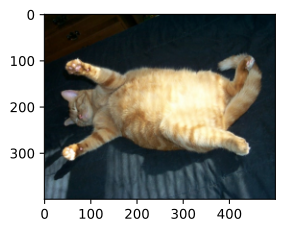

In [2]:
set_figsize()
img = Image.open('./images/cat1.jpg')
plt.imshow(img);

大多数图像增广方法都具有一定的随机性。为了便于观察图像增广的效果，我们下面定义辅助函数`apply`。此函数在输入图像`img`上多次运行图像增广方法`aug`并显示所有结果。


In [3]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    show_images(Y, num_rows, num_cols, scale=scale)

### 12.1.1.1.翻转和裁剪

左右翻转图像通常不会改变对象的类别。这是最早且最广泛使用的图像增广方法之一。接下来，我们使用`transforms`模块来创建`RandomFlipLeftRight`实例，这样就各有50%的几率使图像向左或向右翻转。


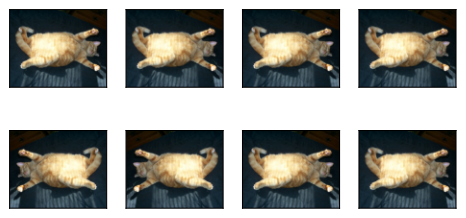

In [4]:
apply(img, torchvision.transforms.RandomHorizontalFlip())

上下翻转图像不如左右图像翻转那样常用。但是，至少对于这个示例图像，上下翻转不会妨碍识别。接下来，我们创建一个`RandomFlipTopBottom`实例，使图像各有50%的几率向上或向下翻转。


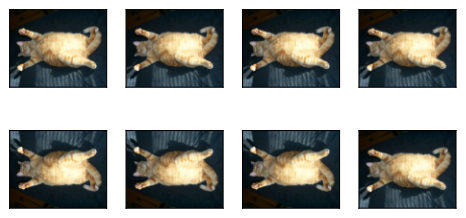

In [5]:
apply(img, torchvision.transforms.RandomVerticalFlip())

在我们使用的示例图像中，猫位于图像的中间，但并非所有图像都是这样。在 [<span style="color: #ffbf00; font-weight: bold;"> 6.5节 </span>](../06_pypto_convolutional_networks/06.05_pooling.ipynb)中，我们解释了汇聚层可以降低卷积层对目标位置的敏感性。另外，我们可以通过对图像进行随机裁剪，使物体以不同的比例出现在图像的不同位置。这也可以降低模型对目标位置的敏感性。

下面的代码将随机裁剪一个面积为原始面积10%到100%的区域，该区域的宽高比从0.5～2之间随机取值。然后，区域的宽度和高度都被缩放到200像素。在本节中（除非另有说明），$a$和$b$之间的随机数指的是在区间$[a, b]$中通过均匀采样获得的连续值。


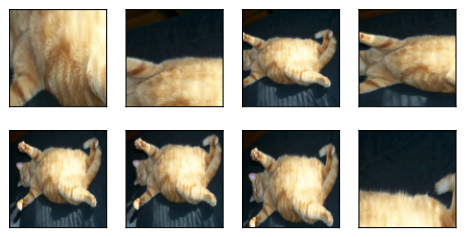

In [6]:
shape_aug = torchvision.transforms.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

### 12.1.1.2.改变颜色

另一种增广方法是改变颜色。我们可以改变图像颜色的四个方面：亮度、对比度、饱和度和色调。在下面的示例中，我们随机更改图像的亮度，随机值为原始图像的50%（$1-0.5$）到150%（$1+0.5$）之间。


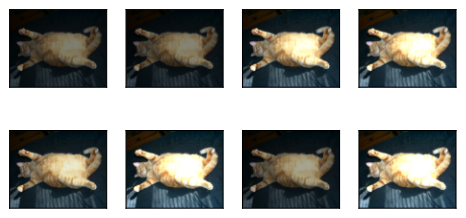

In [7]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))

同样，我们可以随机更改图像的色调。


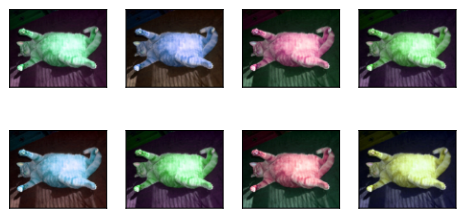

In [8]:
apply(img, torchvision.transforms.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

我们还可以创建一个`RandomColorJitter`实例，并设置如何同时随机更改图像的亮度（`brightness`）、对比度（`contrast`）、饱和度（`saturation`）和色调（`hue`）。


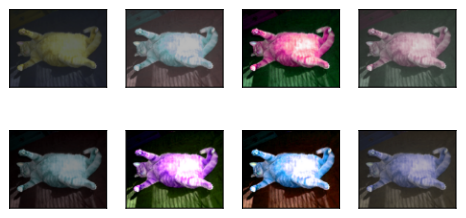

In [9]:
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

### 12.1.1.3.结合多种图像增广方法

在实践中，我们将结合多种图像增广方法。比如，我们可以通过使用一个`Compose`实例来综合上面定义的不同的图像增广方法，并将它们应用到每个图像。


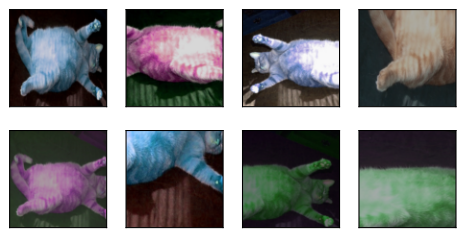

In [10]:
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])
apply(img, augs)

---


## 12.1.2.使用图像增广进行训练

让我们使用图像增广来训练模型。这里，我们使用CIFAR-10数据集，而不是我们之前使用的Fashion-MNIST数据集。这是因为Fashion-MNIST数据集中对象的位置和大小已被规范化，而CIFAR-10数据集中对象的颜色和大小差异更明显。CIFAR-10数据集中的前32个训练图像如下所示。


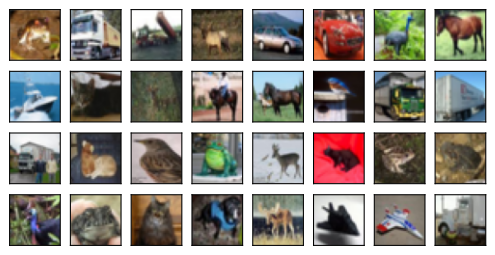

In [11]:
all_images = torchvision.datasets.CIFAR10(train=True, root="../data",
                                          download=True)
show_images([all_images[i][0] for i in range(32)], 4, 8, scale=0.8);

为了在预测过程中得到确切的结果，我们通常对训练样本只进行图像增广，且在预测过程中不使用随机操作的图像增广。在这里，我们只使用最简单的随机左右翻转。此外，我们使用`ToTensor`实例将一批图像转换为深度学习框架所要求的格式，即形状为（批量大小，通道数，高度，宽度）的32位浮点数，取值范围为0～1。


In [12]:
train_augs = torchvision.transforms.Compose([
     torchvision.transforms.RandomHorizontalFlip(),
     torchvision.transforms.ToTensor()])

test_augs = torchvision.transforms.Compose([
     torchvision.transforms.ToTensor()])

接下来，我们定义一个辅助函数，以便于读取图像和应用图像增广。PyTorch 数据集提供的`transform`参数应用图像增广来转化图像。有关`DataLoader`的详细介绍，请参阅 [<span style="color: #ffbf00; font-weight: bold;"> 3.5节 </span>](../03_pypto_linear_networks/03.05_image_classification_dataset.ipynb)。


In [13]:
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(root="../data", train=is_train,
                                           transform=augs, download=True)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                    shuffle=is_train, num_workers=get_dataloader_workers())
    return dataloader

### 12.1.2.1.训练

我们在CIFAR-10数据集上训练 [<span style="color: #ffbf00; font-weight: bold;"> 7.6节 </span>](../07_pypto_modern_convolutional_networks/07.06_resnet.ipynb)中的ResNet-18模型。接下来，我们先定义训练需要使用到的网络，其中使用在之前章节我们定义过的 PyPTO 模块，再定义一个函数，使用 NPU 对模型进行训练和评估。


In [14]:
# PyPTO 算子版 ResNet-18（覆盖 D2LFunction 中的 nn.Conv2d 实现）
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = PyPTOConv2d(input_channels, num_channels,
                                 kernel_size=3, padding=1, stride=strides, bias=True)
        self.conv2 = PyPTOConv2d(num_channels, num_channels,
                                 kernel_size=3, padding=1, bias=True)
        if use_1x1conv:
            self.conv3 = PyPTOConv2d(input_channels, num_channels,
                                     kernel_size=1, stride=strides, bias=True)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)


def resnet18_pypto(num_classes, in_channels=1):
    """PyPTO 算子版 ResNet-18（d2l 修改结构）"""
    def resnet_block(in_channels, out_channels, num_residuals,
                     first_block=False):
        blk = []
        for i in range(num_residuals):
            if i == 0 and not first_block:
                blk.append(Residual(in_channels, out_channels,
                                    use_1x1conv=True, strides=2))
            else:
                blk.append(Residual(out_channels, out_channels))
        return nn.Sequential(*blk)

    net = nn.Sequential(
        PyPTOConv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=True),
        nn.BatchNorm2d(64),
        nn.ReLU())
    net.add_module("resnet_block1", resnet_block(64, 64, 2, first_block=True))
    net.add_module("resnet_block2", resnet_block(64, 128, 2))
    net.add_module("resnet_block3", resnet_block(128, 256, 2))
    net.add_module("resnet_block4", resnet_block(256, 512, 2))
    net.add_module("global_avg_pool", nn.AdaptiveAvgPool2d((1, 1)))
    net.add_module("fc", nn.Sequential(nn.Flatten(),
                                       PyPTOLinear(512, num_classes)))
    return net

In [15]:
def train_batch_ch13(net, X, y, loss, trainer, device):
    """在 NPU 上进行小批量训练"""
    if isinstance(X, list):
        X = [x.to(device) for x in X]
    else:
        X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def train_batch_ch13(net, X, y, loss, trainer, devices):
    &quot;&quot;&quot;用多GPU进行小批量训练&quot;&quot;&quot;
    if isinstance(X, list):
        # 微调BERT中所需
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = d2l.accuracy(pred, y)
    return train_loss_sum, train_acc_sum</pre>
</div>
</details>

In [16]:
def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               device="npu:0"):
    """在 NPU 上进行模型训练（单设备版）"""
    timer, num_batches = Timer(), len(train_iter)
    animator = Animator(xlabel="epoch", xlim=[1, num_epochs], ylim=[0, 1],
                        legend=["train loss", "train acc", "test acc"])
    net = net.to(device)
    for epoch in range(num_epochs):
        metric = Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, device)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(device)}')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=d2l.try_all_gpus()):
    &quot;&quot;&quot;用多GPU进行模型训练&quot;&quot;&quot;
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(xlabel=&#x27;epoch&#x27;, xlim=[1, num_epochs], ylim=[0, 1],
                            legend=[&#x27;train loss&#x27;, &#x27;train acc&#x27;, &#x27;test acc&#x27;])
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        # 4个维度：储存训练损失，训练准确度，实例数，特点数
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f&#x27;loss {metric[0] / metric[2]:.3f}, train acc &#x27;
          f&#x27;{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}&#x27;)
    print(f&#x27;{metric[2] * num_epochs / timer.sum():.1f} examples/sec on &#x27;
          f&#x27;{str(devices)}&#x27;)</pre>
</div>
</details>

现在，我们可以定义`train_with_data_aug`函数，使用图像增广来训练模型。该函数获取所有的GPU，并使用Adam作为训练的优化算法，将图像增广应用于训练集，最后调用刚刚定义的用于训练和评估模型的`train_ch13`函数。


In [17]:
batch_size, device, net = 16, 'npu:0', resnet18_pypto(10, 3)

def init_weights(m):
    if type(m) in (PyPTOLinear, PyPTOConv2d, nn.Linear, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights)

def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, device)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
<summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
<div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
<pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">batch_size, devices, net = 256, d2l.try_all_gpus(), d2l.resnet18(10, 3)</br>
def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)</br>
net.apply(init_weights)</br>
def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction=&quot;none&quot;)
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)</pre>
</div>
</details>

让我们使用基于随机左右翻转的图像增广来训练模型。


loss 0.157, train acc 0.946, test acc 0.850
172.1 examples/sec on npu:0


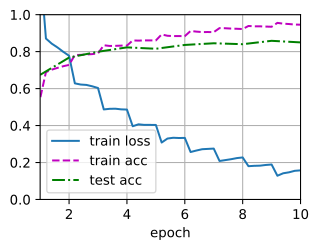

In [18]:
train_with_data_aug(train_augs, test_augs, net)

---


## 12.1.3.小结

* 图像增广基于现有的训练数据生成随机图像，来提高模型的泛化能力。
* 为了在预测过程中得到确切的结果，我们通常对训练样本只进行图像增广，而在预测过程中不使用带随机操作的图像增广。
* 深度学习框架提供了许多不同的图像增广方法，这些方法可以被同时应用。



---


## 12.1.4.练习

1. 在不使用图像增广的情况下训练模型：`train_with_data_aug(no_aug, no_aug)`。比较使用和不使用图像增广的训练结果和测试精度。这个对比实验能支持图像增广可以减轻过拟合的论点吗？为什么？
2. 在基于CIFAR-10数据集的模型训练中结合多种不同的图像增广方法。它能提高测试准确性吗？
3. 参阅深度学习框架的在线文档。它还提供了哪些其他的图像增广方法？


参考答案详见 [answers/12.01_reference_answer](./answers/12.01_reference_answer.ipynb)。

### 12.1.4.1.参考答案（PyPTO）


In [ ]:
!cat answers/txt/12.01_reference_answer_pypto.txt

### 12.1.4.2.参考答案（PyTorch）


In [ ]:
!cat answers/txt/12.01_reference_answer_pytorch.txt